<a href="https://colab.research.google.com/github/muajnstu/CAST/blob/main/E3_expectation_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import friedmanchisquare, rankdata
from itertools import combinations
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch

RPI


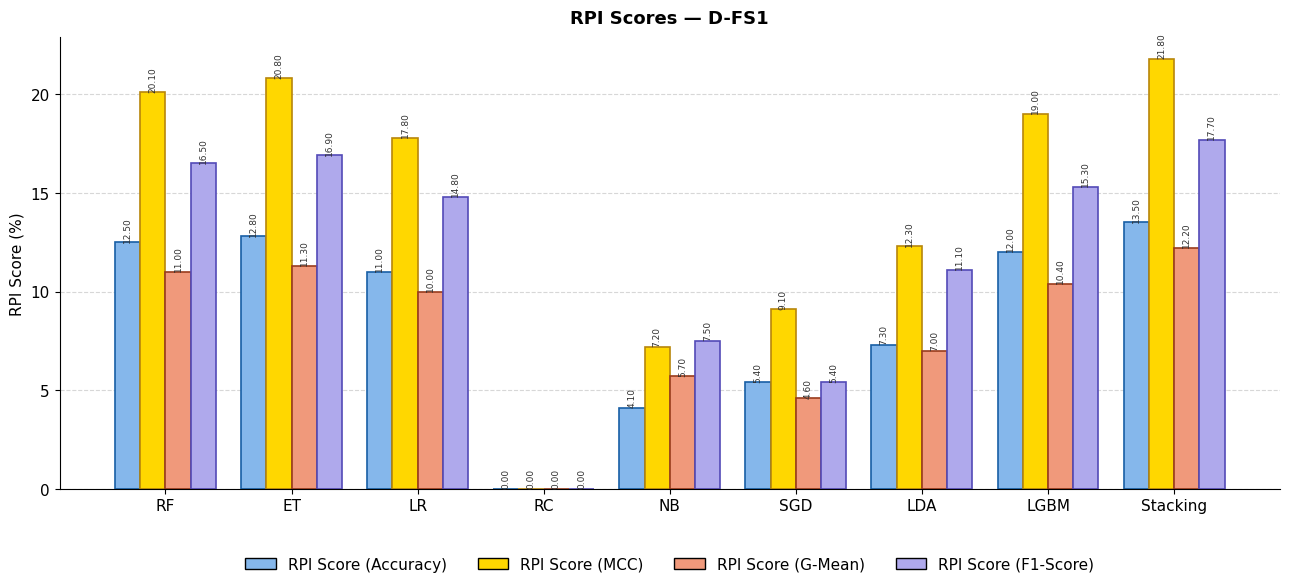

Saved: rpi_D_FS1.png


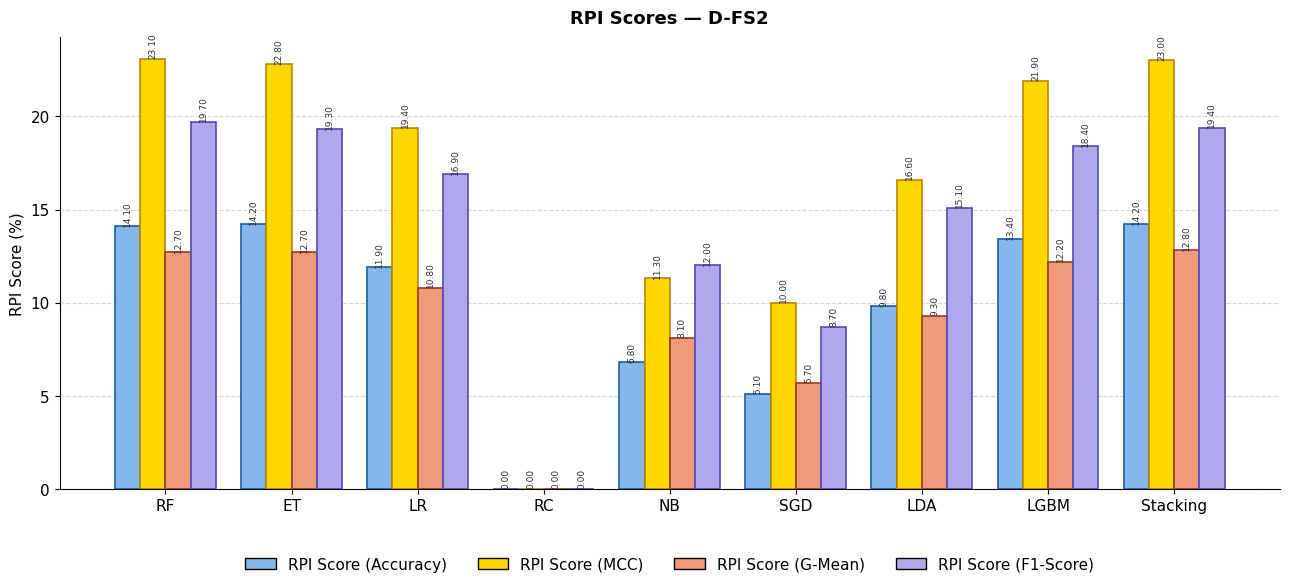

Saved: rpi_D_FS2.png


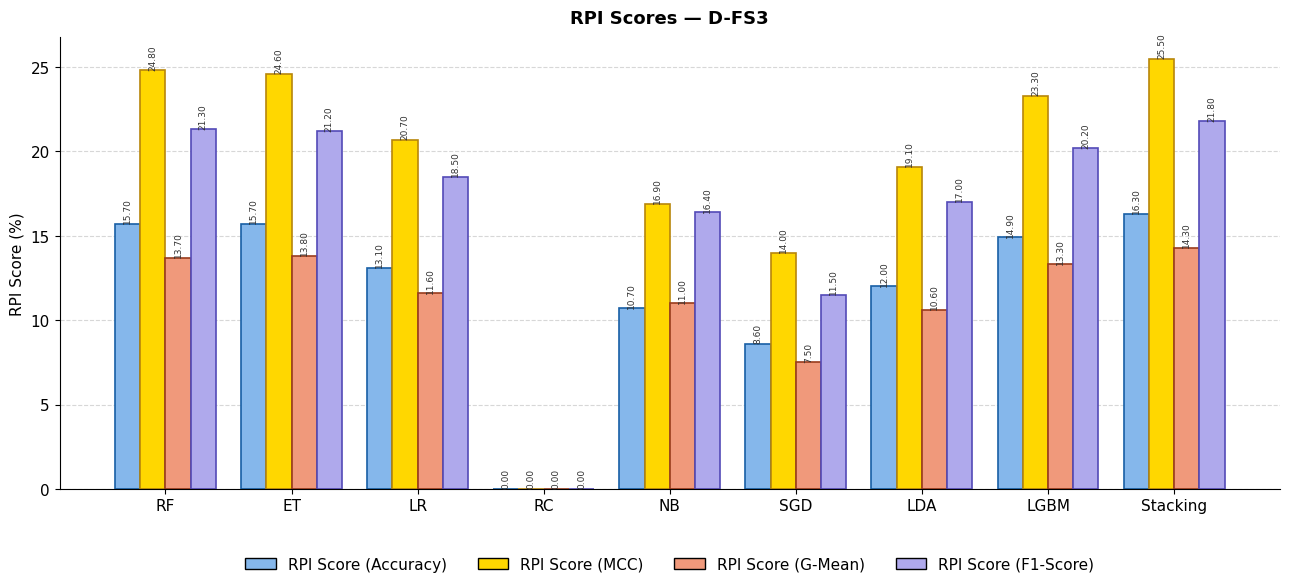

Saved: rpi_D_FS3.png


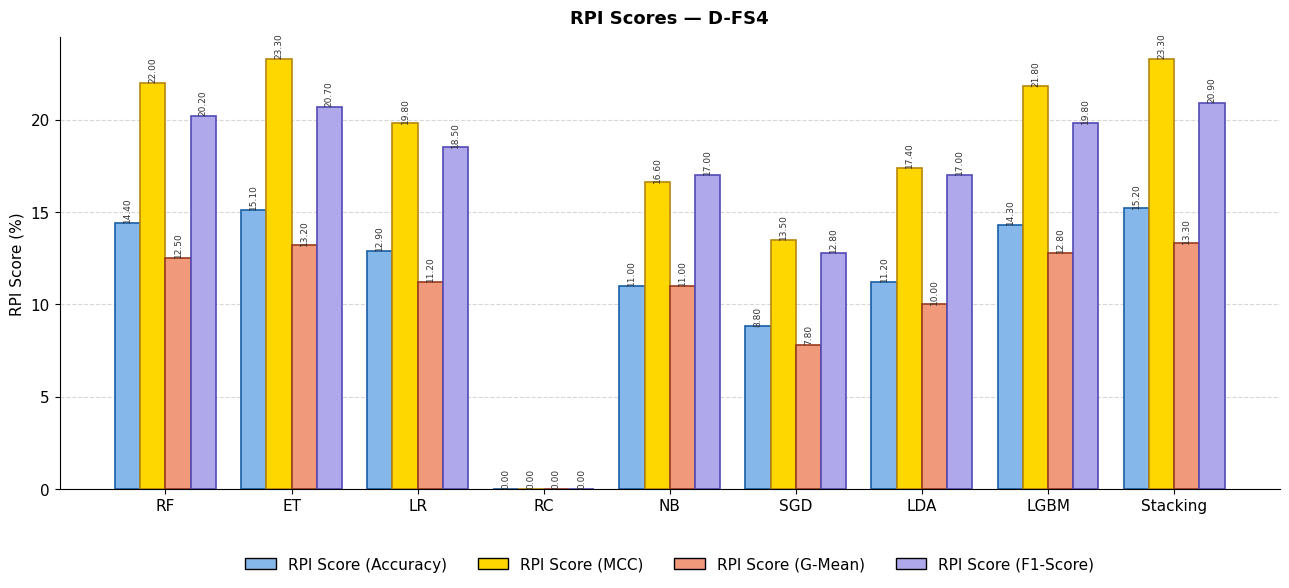

Saved: rpi_D_FS4.png


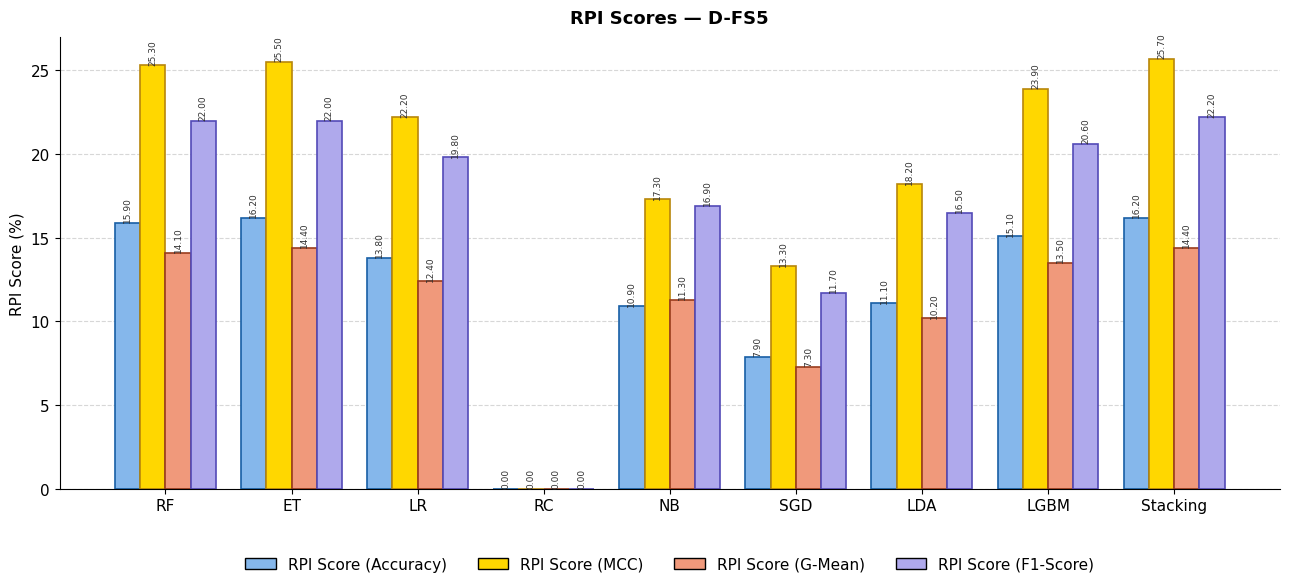

Saved: rpi_D_FS5.png


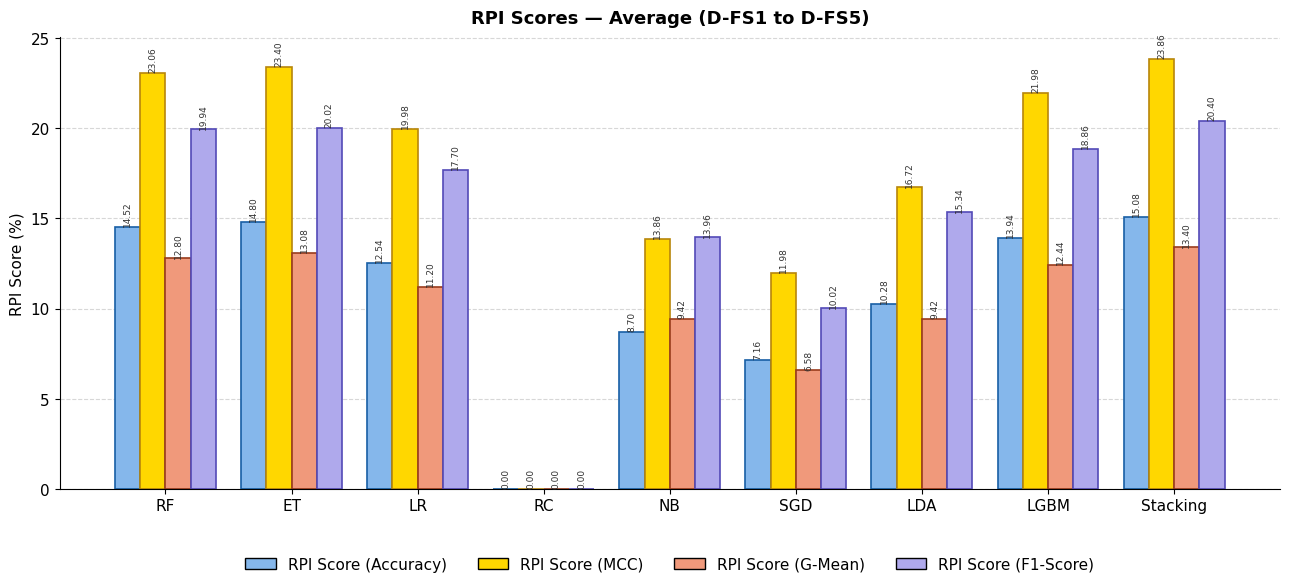

Saved: rpi_average_all.png


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

raw = {
    "D-FS1": {
        "RF":       [0.965, 0.935, 0.961, 0.952],
        "ET":       [0.968, 0.942, 0.964, 0.956],
        "LR":       [0.950, 0.912, 0.951, 0.935],
        "RC":       [0.840, 0.734, 0.851, 0.787],
        "NB":       [0.881, 0.806, 0.908, 0.862],
        "SGD":      [0.894, 0.825, 0.897, 0.841],
        "LDA":      [0.913, 0.857, 0.921, 0.898],
        "LGBM":     [0.960, 0.924, 0.955, 0.940],
        "Stacking": [0.975, 0.952, 0.973, 0.964],
    },
    "D-FS2": {
        "RF":       [0.971, 0.947, 0.967, 0.960],
        "ET":       [0.972, 0.944, 0.967, 0.956],
        "LR":       [0.949, 0.910, 0.948, 0.932],
        "RC":       [0.830, 0.716, 0.840, 0.763],
        "NB":       [0.898, 0.829, 0.921, 0.883],
        "SGD":      [0.881, 0.816, 0.897, 0.850],
        "LDA":      [0.928, 0.882, 0.933, 0.914],
        "LGBM":     [0.964, 0.935, 0.962, 0.947],
        "Stacking": [0.972, 0.946, 0.968, 0.957],
    },
    "D-FS3": {
        "RF":       [0.969, 0.943, 0.965, 0.957],
        "ET":       [0.969, 0.941, 0.966, 0.956],
        "LR":       [0.943, 0.902, 0.944, 0.929],
        "RC":       [0.812, 0.695, 0.828, 0.744],
        "NB":       [0.919, 0.864, 0.938, 0.908],
        "SGD":      [0.898, 0.835, 0.903, 0.859],
        "LDA":      [0.932, 0.886, 0.934, 0.914],
        "LGBM":     [0.961, 0.928, 0.961, 0.946],
        "Stacking": [0.975, 0.950, 0.971, 0.962],
    },
    "D-FS4": {
        "RF":       [0.964, 0.934, 0.961, 0.952],
        "ET":       [0.971, 0.947, 0.968, 0.957],
        "LR":       [0.949, 0.912, 0.948, 0.935],
        "RC":       [0.820, 0.714, 0.836, 0.750],
        "NB":       [0.930, 0.880, 0.946, 0.920],
        "SGD":      [0.908, 0.849, 0.914, 0.878],
        "LDA":      [0.932, 0.888, 0.936, 0.920],
        "LGBM":     [0.963, 0.932, 0.964, 0.948],
        "Stacking": [0.972, 0.947, 0.969, 0.959],
    },
    "D-FS5": {
        "RF":       [0.971, 0.947, 0.968, 0.961],
        "ET":       [0.974, 0.949, 0.971, 0.961],
        "LR":       [0.950, 0.916, 0.951, 0.939],
        "RC":       [0.812, 0.694, 0.827, 0.741],
        "NB":       [0.921, 0.867, 0.940, 0.910],
        "SGD":      [0.891, 0.827, 0.900, 0.858],
        "LDA":      [0.923, 0.876, 0.929, 0.906],
        "LGBM":     [0.963, 0.933, 0.962, 0.947],
        "Stacking": [0.974, 0.951, 0.971, 0.963],
    },
}

datasets   = ["D-FS1", "D-FS2", "D-FS3", "D-FS4", "D-FS5"]
models     = ["RF", "ET", "LR", "RC", "NB", "SGD", "LDA", "LGBM", "Stacking"]
metrics    = ["Accuracy", "MCC", "G-Mean", "F1-Score"]   # AUROC বাদ

style = {
    "Accuracy": dict(color="#85B7EB", edgecolor="#185FA5", linewidth=1.2),
    "MCC":      dict(color="#FFD700", edgecolor="#B8860B", linewidth=1.2),
    "G-Mean":   dict(color="#F0997B", edgecolor="#993C1D", linewidth=1.2),
    "F1-Score": dict(color="#AFA9EC", edgecolor="#534AB7", linewidth=1.2),
}

bar_width = 0.20
x         = np.arange(len(models))
n_metrics = len(metrics)
offsets   = np.linspace(-(n_metrics - 1) / 2,
                         (n_metrics - 1) / 2,
                         n_metrics) * bar_width


def compute_rpi(ds_data):
    rpi = {m: [] for m in models}
    for ki in range(len(metrics)):
        valid_vals = [ds_data[m][ki] for m in models if ds_data[m][ki] is not None]
        min_v = min(valid_vals) if valid_vals else 0
        for m in models:
            v = ds_data[m][ki]
            rpi[m].append((v - min_v) * 100 if v is not None else None)
    return rpi


def draw_chart(ax, rpi, title):
    for j, metric in enumerate(metrics):
        vals = [rpi[m][j] if rpi[m][j] is not None else 0.0 for m in models]

        bars = ax.bar(x + offsets[j], vals, width=bar_width,
                      label=metric, **style[metric])

        for bar, m in zip(bars, models):
            v = rpi[m][j]
            if v is None:
                continue
            ypos = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                ypos + 0.02,
                f"{v:.2f}",
                ha="center", va="bottom",
                fontsize=6.5, color="#333333",
                rotation=90
            )

    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylabel("RPI Score (%)", fontsize=11)
    ax.tick_params(axis="y", labelsize=11)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


legend_handles = [
    mpatches.Patch(
        label=f"RPI Score ({m})",
        facecolor=style[m]["color"],
        edgecolor="black"
    )
    for m in metrics
]

# ── ১. প্রতিটা dataset আলাদা graph ────────────────────────────────────────────
for ds in datasets:
    rpi = compute_rpi(raw[ds])

    fig, ax = plt.subplots(figsize=(13, 6))
    draw_chart(ax, rpi, f"RPI Scores — {ds}")

    ax.legend(handles=legend_handles, loc="upper center",
              bbox_to_anchor=(0.5, -0.12), ncol=4,
              fontsize=11, frameon=False)

    plt.tight_layout()
    fname = f"rpi_{ds.replace('-', '_')}.png"
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

# ── ২. সব dataset এর average করে একটা combined graph ─────────────────────────
avg_rpi = {m: [0.0] * len(metrics) for m in models}

for ds in datasets:
    rpi = compute_rpi(raw[ds])
    for m in models:
        for ki in range(len(metrics)):
            avg_rpi[m][ki] += (rpi[m][ki] if rpi[m][ki] is not None else 0.0) / len(datasets)

fig, ax = plt.subplots(figsize=(13, 6))
draw_chart(ax, {m: avg_rpi[m] for m in models}, "RPI Scores — Average (D-FS1 to D-FS5)")

ax.legend(handles=legend_handles, loc="upper center",
          bbox_to_anchor=(0.5, -0.12), ncol=4,
          fontsize=11, frameon=False)

plt.tight_layout()
plt.savefig("rpi_average_all.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: rpi_average_all.png")

CDD

Friedman: stat=39.0918,  p=0.000005
CD = 5.2481

Significantly different pairs:
  Stacking vs NB
  Stacking vs SGD
  Stacking vs RC
  RF vs SGD
  RF vs RC
  ET vs SGD
  ET vs RC


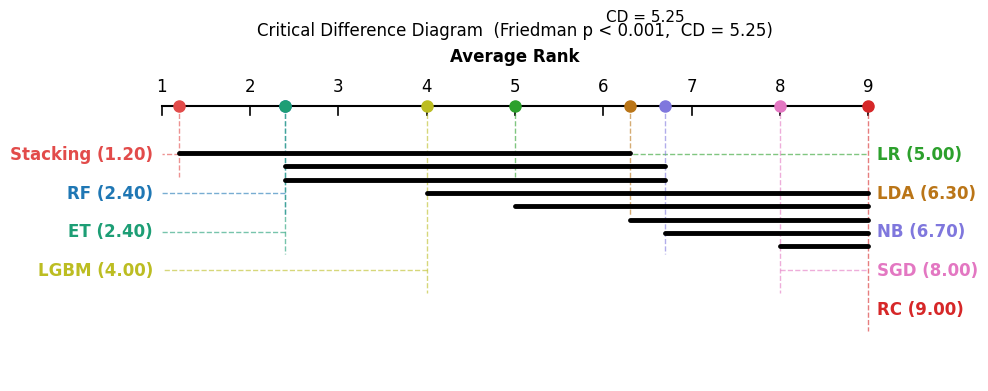

Done. Saved as cd_diagram.png


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import friedmanchisquare, rankdata
from itertools import combinations

# ── RAW DATA (Experiment_3_expectation_Performance_Result.xlsx থেকে) ──────────
# format: [Accuracy, MCC, G-Mean, F1-Score, AUROC]
# AUROC = None যেখানে applicable না (RC, SGD)

raw = {
    "D-FS1": {
        "RF":       [0.965, 0.935, 0.961, 0.952],
        "ET":       [0.968, 0.942, 0.964, 0.956],
        "LR":       [0.950, 0.912, 0.951, 0.935],
        "RC":       [0.840, 0.734, 0.851, 0.787],
        "NB":       [0.881, 0.806, 0.908, 0.862],
        "SGD":      [0.894, 0.825, 0.897, 0.841],
        "LDA":      [0.913, 0.857, 0.921, 0.898],
        "LGBM":     [0.960, 0.924, 0.955, 0.940],
        "Stacking": [0.975, 0.952, 0.973, 0.964],
    },
    "D-FS2": {
        "RF":       [0.971, 0.947, 0.967, 0.960],
        "ET":       [0.972, 0.944, 0.967, 0.956],
        "LR":       [0.949, 0.910, 0.948, 0.932],
        "RC":       [0.830, 0.716, 0.840, 0.763],
        "NB":       [0.898, 0.829, 0.921, 0.883],
        "SGD":      [0.881, 0.816, 0.897, 0.850],
        "LDA":      [0.928, 0.882, 0.933, 0.914],
        "LGBM":     [0.964, 0.935, 0.962, 0.947],
        "Stacking": [0.972, 0.946, 0.968, 0.957],
    },
    "D-FS3": {
        "RF":       [0.969, 0.943, 0.965, 0.957],
        "ET":       [0.969, 0.941, 0.966, 0.956],
        "LR":       [0.943, 0.902, 0.944, 0.929],
        "RC":       [0.812, 0.695, 0.828, 0.744],
        "NB":       [0.919, 0.864, 0.938, 0.908],
        "SGD":      [0.898, 0.835, 0.903, 0.859],
        "LDA":      [0.932, 0.886, 0.934, 0.914],
        "LGBM":     [0.961, 0.928, 0.961, 0.946],
        "Stacking": [0.975, 0.950, 0.971, 0.962],
    },
    "D-FS4": {
        "RF":       [0.964, 0.934, 0.961, 0.952],
        "ET":       [0.971, 0.947, 0.968, 0.957],
        "LR":       [0.949, 0.912, 0.948, 0.935],
        "RC":       [0.820, 0.714, 0.836, 0.750],
        "NB":       [0.930, 0.880, 0.946, 0.920],
        "SGD":      [0.908, 0.849, 0.914, 0.878],
        "LDA":      [0.932, 0.888, 0.936, 0.920],
        "LGBM":     [0.963, 0.932, 0.964, 0.948],
        "Stacking": [0.972, 0.947, 0.969, 0.959],
    },
    "D-FS5": {
        "RF":       [0.971, 0.947, 0.968, 0.961],
        "ET":       [0.974, 0.949, 0.971, 0.961],
        "LR":       [0.950, 0.916, 0.951, 0.939],
        "RC":       [0.812, 0.694, 0.827, 0.741],
        "NB":       [0.921, 0.867, 0.940, 0.910],
        "SGD":      [0.891, 0.827, 0.900, 0.858],
        "LDA":      [0.923, 0.876, 0.929, 0.906],
        "LGBM":     [0.963, 0.933, 0.962, 0.947],
        "Stacking": [0.974, 0.951, 0.971, 0.963],
    },
}

# ── CONFIG ────────────────────────────────────────────────────────────────────

datasets = ["D-FS1", "D-FS2", "D-FS3", "D-FS4", "D-FS5"]
models   = ["RF", "ET", "LR", "RC", "NB", "SGD", "LDA", "LGBM", "Stacking"]

N = len(datasets)
k = len(models)

# ── STEP 1: SCORES (Accuracy, MCC, G-Mean, F1-Score — AUROC বাদ) ─────────────

scores = np.zeros((N, k))
for i, ds in enumerate(datasets):
    for j, model in enumerate(models):
        vals = [v for v in raw[ds][model][:4] if v is not None]
        scores[i, j] = np.mean(vals) if vals else np.nan

# ── STEP 2: RANKS ─────────────────────────────────────────────────────────────

ranks = np.zeros_like(scores)
for i in range(N):
    ranks[i] = rankdata(-scores[i])

mean_ranks = ranks.mean(axis=0)

# ── STEP 3: FRIEDMAN TEST ─────────────────────────────────────────────────────

stat, p_value = friedmanchisquare(*[ranks[:, j] for j in range(k)])
print(f"Friedman: stat={stat:.4f},  p={p_value:.6f}")

# ── STEP 4: NEMENYI (k=9, alpha=0.05) ────────────────────────────────────────

q_alpha = 3.03
CD      = q_alpha * np.sqrt(k * (k + 1) / (6 * N))
print(f"CD = {CD:.4f}")

sorted_idx   = np.argsort(mean_ranks)
sorted_names = [models[i] for i in sorted_idx]
sorted_ranks = mean_ranks[sorted_idx]

sig_pairs = []
for (i, j) in combinations(range(k), 2):
    if abs(sorted_ranks[i] - sorted_ranks[j]) > CD:
        sig_pairs.append((sorted_names[i], sorted_names[j]))

print("\nSignificantly different pairs:")
for p in sig_pairs:
    print(f"  {p[0]} vs {p[1]}")

# ── STEP 5: COLORS ────────────────────────────────────────────────────────────

initial_colors_map = {
    "ET":       "#1D9E75",
    "NB":       "#7F77DD",
    "LDA":      "#BA7517",
    "Stacking": "#E24B4A",
}

cmap_tab   = plt.colormaps["tab10"].resampled(k)
colors_map = {}
for idx, model_name in enumerate(models):
    if model_name in initial_colors_map:
        colors_map[model_name] = initial_colors_map[model_name]
    else:
        colors_map[model_name] = mcolors.to_hex(cmap_tab(idx))

# ── STEP 6: CD DIAGRAM ────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlim(0.5, k + 0.5)
ax.set_ylim(-2.5, 2.0)
ax.axis("off")

axis_y = 1.2

# rank axis
ax.plot([1, k], [axis_y, axis_y], color="black", lw=1.5)
for r in range(1, k + 1):
    ax.plot([r, r], [axis_y, axis_y - 0.12], color="black", lw=1.2)
    ax.text(r, axis_y + 0.15, str(r), ha="center", va="bottom",
            fontsize=12, color="black")
ax.text((1 + k) / 2, axis_y + 0.55, "Average Rank",
        ha="center", va="bottom", fontsize=12, fontweight="bold")

# CD bar
cd_x_start = k - CD + 0.1
cd_y       = axis_y + 0.95
ax.annotate("", xy=(k + 0.1, cd_y), xytext=(cd_x_start, cd_y),
            arrowprops=dict(arrowstyle="-", color="black", lw=1.5))
ax.plot([cd_x_start, cd_x_start], [cd_y - 0.08, cd_y + 0.08], color="black", lw=1.5)
ax.plot([k + 0.1,    k + 0.1],    [cd_y - 0.08, cd_y + 0.08], color="black", lw=1.5)
ax.text((cd_x_start + k + 0.1) / 2, cd_y + 0.15, f"CD = {CD:.2f}",
         ha="center", va="bottom", fontsize=11)

# labels: left half / right half
n_left       = k // 2
label_y_top  =  0.55
label_y_step =  0.52
line_drop    = -0.30

for pos, (name, rank) in enumerate(zip(sorted_names, sorted_ranks)):
    color = colors_map[name]
    ax.plot(rank, axis_y, "o", color=color, ms=8, zorder=5)

    if pos < n_left:
        ly = label_y_top - pos * label_y_step
        ax.plot([rank, rank], [axis_y, axis_y + line_drop + (ly - axis_y)],
                color=color, lw=1.0, ls="--", alpha=0.6)
        ax.plot([rank, 1.0], [ly, ly], color=color, lw=1.0, ls="--", alpha=0.6)
        ax.text(0.9, ly, f"{name} ({rank:.2f})",
                ha="right", va="center", fontsize=12,
                color=color, fontweight="bold")
    else:
        rpos = pos - n_left
        ly   = label_y_top - rpos * label_y_step
        ax.plot([rank, rank], [axis_y, axis_y + line_drop + (ly - axis_y)],
                color=color, lw=1.0, ls="--", alpha=0.6)
        ax.plot([rank, k + 0.0], [ly, ly], color=color, lw=1.0, ls="--", alpha=0.6)
        ax.text(k + 0.1, ly, f"{name} ({rank:.2f})",
                ha="left", va="center", fontsize=12,
                color=color, fontweight="bold")

# clique bars
clique_y    = axis_y - 0.45
clique_step = 0.18
drawn       = []

for i in range(k):
    group = [i]
    for j in range(i + 1, k):
        pair   = (sorted_names[i], sorted_names[j])
        pair_r = (sorted_names[j], sorted_names[i])
        if pair not in sig_pairs and pair_r not in sig_pairs:
            group.append(j)
    if len(group) > 1:
        key = tuple(group)
        if key not in drawn:
            drawn.append(key)
            bar_y   = clique_y - len(drawn) * clique_step
            x_start = sorted_ranks[group[0]]
            x_end   = sorted_ranks[group[-1]]
            ax.plot([x_start, x_end], [bar_y, bar_y],
                    color="black", lw=3.5, solid_capstyle="round")

sig_str = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.4f}"
ax.set_title(
    f"Critical Difference Diagram  (Friedman {sig_str},  CD = {CD:.2f})",
    fontsize=12, pad=8)

plt.tight_layout()
plt.savefig("cd_diagram.png", dpi=300, bbox_inches="tight")
plt.show()
print("Done. Saved as cd_diagram.png")


  D-FS1  |  Friedman p = 0.0001  |  CD = 5.87
Significantly different pairs:
  Stacking vs NB
  Stacking vs SGD
  Stacking vs RC
  ET vs RC
  RF vs RC


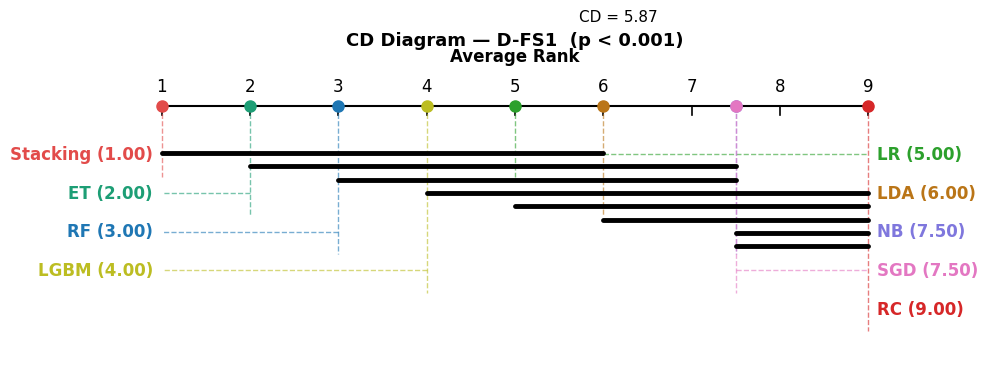

Saved: cd_D_FS1.png

  D-FS2  |  Friedman p = 0.0001  |  CD = 5.87
Significantly different pairs:
  Stacking vs SGD
  Stacking vs RC
  RF vs SGD
  RF vs RC
  ET vs RC


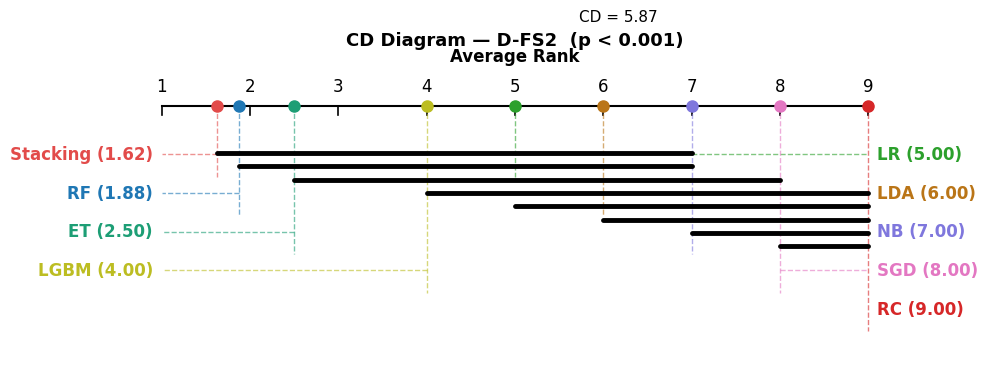

Saved: cd_D_FS2.png

  D-FS3  |  Friedman p = 0.0001  |  CD = 5.87
Significantly different pairs:
  Stacking vs SGD
  Stacking vs RC
  RF vs RC
  ET vs RC


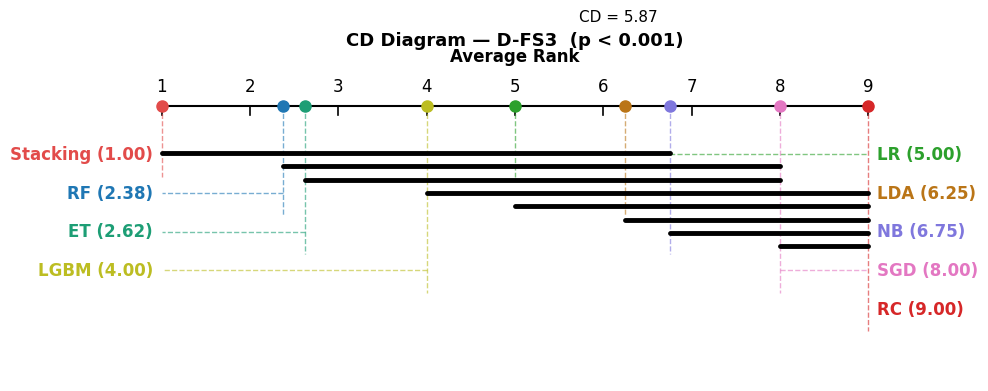

Saved: cd_D_FS3.png

  D-FS4  |  Friedman p = 0.0001  |  CD = 5.87
Significantly different pairs:
  Stacking vs SGD
  Stacking vs RC
  ET vs SGD
  ET vs RC


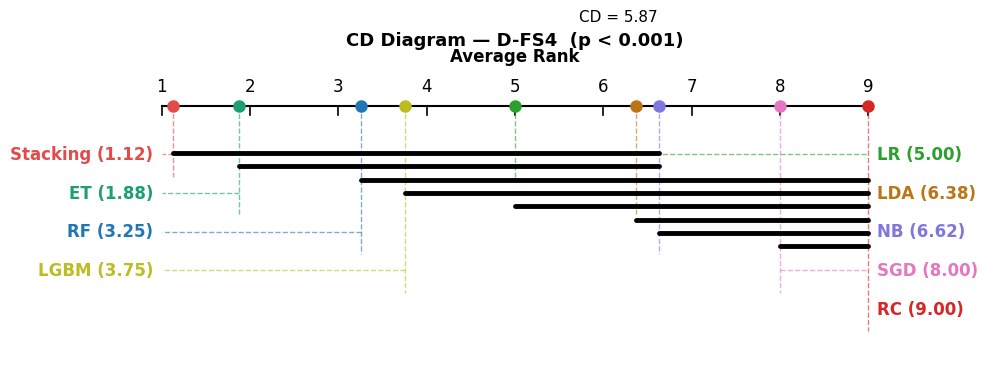

Saved: cd_D_FS4.png

  D-FS5  |  Friedman p = 0.0001  |  CD = 5.87
Significantly different pairs:
  Stacking vs SGD
  Stacking vs RC
  ET vs SGD
  ET vs RC
  RF vs RC


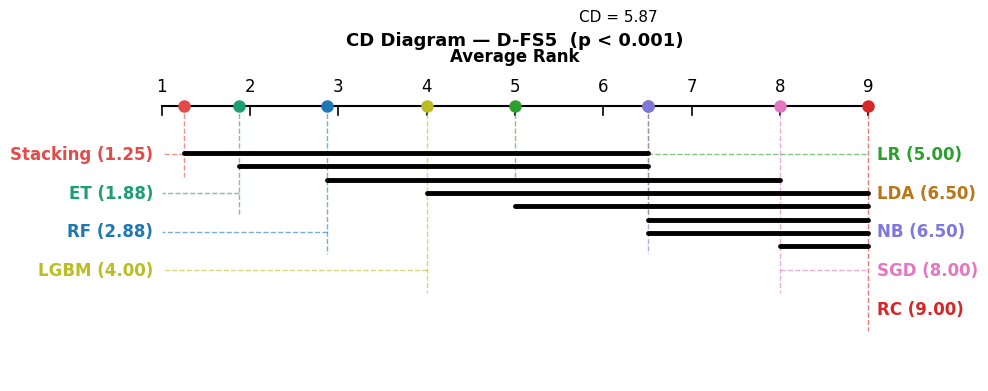

Saved: cd_D_FS5.png


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from scipy.stats import friedmanchisquare, rankdata
from itertools import combinations

raw = {
    "D-FS1": {
        "RF":       [0.965, 0.935, 0.961, 0.952],
        "ET":       [0.968, 0.942, 0.964, 0.956],
        "LR":       [0.950, 0.912, 0.951, 0.935],
        "RC":       [0.840, 0.734, 0.851, 0.787],
        "NB":       [0.881, 0.806, 0.908, 0.862],
        "SGD":      [0.894, 0.825, 0.897, 0.841],
        "LDA":      [0.913, 0.857, 0.921, 0.898],
        "LGBM":     [0.960, 0.924, 0.955, 0.940],
        "Stacking": [0.975, 0.952, 0.973, 0.964],
    },
    "D-FS2": {
        "RF":       [0.971, 0.947, 0.967, 0.960],
        "ET":       [0.972, 0.944, 0.967, 0.956],
        "LR":       [0.949, 0.910, 0.948, 0.932],
        "RC":       [0.830, 0.716, 0.840, 0.763],
        "NB":       [0.898, 0.829, 0.921, 0.883],
        "SGD":      [0.881, 0.816, 0.897, 0.850],
        "LDA":      [0.928, 0.882, 0.933, 0.914],
        "LGBM":     [0.964, 0.935, 0.962, 0.947],
        "Stacking": [0.972, 0.946, 0.968, 0.957],
    },
    "D-FS3": {
        "RF":       [0.969, 0.943, 0.965, 0.957],
        "ET":       [0.969, 0.941, 0.966, 0.956],
        "LR":       [0.943, 0.902, 0.944, 0.929],
        "RC":       [0.812, 0.695, 0.828, 0.744],
        "NB":       [0.919, 0.864, 0.938, 0.908],
        "SGD":      [0.898, 0.835, 0.903, 0.859],
        "LDA":      [0.932, 0.886, 0.934, 0.914],
        "LGBM":     [0.961, 0.928, 0.961, 0.946],
        "Stacking": [0.975, 0.950, 0.971, 0.962],
    },
    "D-FS4": {
        "RF":       [0.964, 0.934, 0.961, 0.952],
        "ET":       [0.971, 0.947, 0.968, 0.957],
        "LR":       [0.949, 0.912, 0.948, 0.935],
        "RC":       [0.820, 0.714, 0.836, 0.750],
        "NB":       [0.930, 0.880, 0.946, 0.920],
        "SGD":      [0.908, 0.849, 0.914, 0.878],
        "LDA":      [0.932, 0.888, 0.936, 0.920],
        "LGBM":     [0.963, 0.932, 0.964, 0.948],
        "Stacking": [0.972, 0.947, 0.969, 0.959],
    },
    "D-FS5": {
        "RF":       [0.971, 0.947, 0.968, 0.961],
        "ET":       [0.974, 0.949, 0.971, 0.961],
        "LR":       [0.950, 0.916, 0.951, 0.939],
        "RC":       [0.812, 0.694, 0.827, 0.741],
        "NB":       [0.921, 0.867, 0.940, 0.910],
        "SGD":      [0.891, 0.827, 0.900, 0.858],
        "LDA":      [0.923, 0.876, 0.929, 0.906],
        "LGBM":     [0.963, 0.933, 0.962, 0.947],
        "Stacking": [0.974, 0.951, 0.971, 0.963],
    },
}

datasets = ["D-FS1", "D-FS2", "D-FS3", "D-FS4", "D-FS5"]
models   = ["RF", "ET", "LR", "RC", "NB", "SGD", "LDA", "LGBM", "Stacking"]
metrics  = ["Accuracy", "MCC", "G-Mean", "F1-Score"]

# ── colors ────────────────────────────────────────────────────────────────────
initial_colors_map = {
    "ET":       "#1D9E75",
    "NB":       "#7F77DD",
    "LDA":      "#BA7517",
    "Stacking": "#E24B4A",
}
cmap = plt.colormaps['tab10'].resampled(len(models))
colors_map = {}
for idx, m in enumerate(models):
    colors_map[m] = initial_colors_map.get(m, mcolors.to_hex(cmap(idx)))

q_alpha = 3.03  # Nemenyi, alpha=0.05, k=9

# ── একটা dataset এর জন্য CD diagram ─────────────────────────────────────────
def plot_cd_diagram(ds):
    metric_idx = {"Accuracy": 0, "MCC": 1, "G-Mean": 2, "F1-Score": 3}

    scores = np.full((len(metrics), len(models)), np.nan)
    for i, metric in enumerate(metrics):
        k_idx = metric_idx[metric]
        for j, model in enumerate(models):
            val = raw[ds][model][k_idx]
            if val is not None:
                scores[i, j] = val

    # rank per metric row (NaN = worst)
    ranks = np.zeros_like(scores)
    for i in range(len(metrics)):
        row = scores[i]
        filled = np.where(np.isnan(row), -np.inf, row)
        ranks[i] = rankdata(-filled)

    mean_ranks = ranks.mean(axis=0)
    N = len(metrics)
    k = len(models)

    # Friedman test
    stat, p_value = friedmanchisquare(*[ranks[:, j] for j in range(k)])

    # CD
    CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))

    sorted_idx   = np.argsort(mean_ranks)
    sorted_names = [models[i] for i in sorted_idx]
    sorted_ranks = mean_ranks[sorted_idx]

    sig_pairs = []
    for (i, j) in combinations(range(k), 2):
        if abs(sorted_ranks[i] - sorted_ranks[j]) > CD:
            sig_pairs.append((sorted_names[i], sorted_names[j]))

    print(f"\n{'='*40}")
    print(f"  {ds}  |  Friedman p = {p_value:.4f}  |  CD = {CD:.2f}")
    print(f"{'='*40}")
    print("Significantly different pairs:")
    for p in sig_pairs:
        print(f"  {p[0]} vs {p[1]}")

    # ── figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.set_xlim(0.5, k + 0.5)
    ax.set_ylim(-2.5, 2.0)
    ax.axis("off")

    axis_y = 1.2
    ax.plot([1, k], [axis_y, axis_y], color="black", lw=1.5)
    for r in range(1, k + 1):
        ax.plot([r, r], [axis_y, axis_y - 0.12], color="black", lw=1.2)
        ax.text(r, axis_y + 0.15, str(r), ha="center", va="bottom",
                fontsize=12, color="black")
    ax.text((1 + k) / 2, axis_y + 0.55, "Average Rank",
            ha="center", va="bottom", fontsize=12, fontweight="bold")

    # CD bar
    cd_x_start = k - CD + 0.1
    cd_y       = axis_y + 0.95
    ax.annotate("", xy=(k + 0.1, cd_y), xytext=(cd_x_start, cd_y),
                arrowprops=dict(arrowstyle="-", color="black", lw=1.5))
    ax.plot([cd_x_start, cd_x_start], [cd_y - 0.08, cd_y + 0.08], color="black", lw=1.5)
    ax.plot([k + 0.1, k + 0.1],       [cd_y - 0.08, cd_y + 0.08], color="black", lw=1.5)
    ax.text((cd_x_start + k + 0.1) / 2, cd_y + 0.15,
            f"CD = {CD:.2f}", ha="center", va="bottom", fontsize=11)

    # model labels
    n_left        = k // 2
    label_y_top   = 0.55
    label_y_step  = 0.52
    line_drop     = -0.30

    for pos, (name, rank) in enumerate(zip(sorted_names, sorted_ranks)):
        color = colors_map[name]
        ax.plot(rank, axis_y, "o", color=color, ms=8, zorder=5)

        if pos < n_left:
            ly = label_y_top - pos * label_y_step
            ax.plot([rank, rank], [axis_y, axis_y + line_drop + (ly - axis_y)],
                    color=color, lw=1.0, ls="--", alpha=0.6)
            ax.plot([rank, 1.0], [ly, ly], color=color, lw=1.0, ls="--", alpha=0.6)
            ax.text(0.9, ly, f"{name} ({rank:.2f})",
                    ha="right", va="center", fontsize=12,
                    color=color, fontweight="bold")
        else:
            rpos = pos - n_left
            ly   = label_y_top - rpos * label_y_step
            ax.plot([rank, rank], [axis_y, axis_y + line_drop + (ly - axis_y)],
                    color=color, lw=1.0, ls="--", alpha=0.6)
            ax.plot([rank, k + 0.0], [ly, ly], color=color, lw=1.0, ls="--", alpha=0.6)
            ax.text(k + 0.1, ly, f"{name} ({rank:.2f})",
                    ha="left", va="center", fontsize=12,
                    color=color, fontweight="bold")

    # clique bars (non-significantly different groups)
    clique_y    = axis_y - 0.45
    clique_step = 0.18
    drawn = []

    for i in range(k):
        group = [i]
        for j in range(i + 1, k):
            pair   = (sorted_names[i], sorted_names[j])
            pair_r = (sorted_names[j], sorted_names[i])
            if pair not in sig_pairs and pair_r not in sig_pairs:
                group.append(j)
        if len(group) > 1:
            key = tuple(group)
            if key not in drawn:
                drawn.append(key)
                bar_y   = clique_y - len(drawn) * clique_step
                x_start = sorted_ranks[group[0]]
                x_end   = sorted_ranks[group[-1]]
                ax.plot([x_start, x_end], [bar_y, bar_y],
                        color="black", lw=3.5, solid_capstyle="round")

    sig_str = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.4f}"
    ax.set_title(f"CD Diagram — {ds}  ({sig_str})",
                 fontsize=13, fontweight="bold", y=0.98)

    plt.tight_layout()
    fname = f"cd_{ds.replace('-', '_')}.png"
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

# ── 5টা dataset এর জন্য loop ─────────────────────────────────────────────────
for ds in datasets:
    plot_cd_diagram(ds)

HeatMap


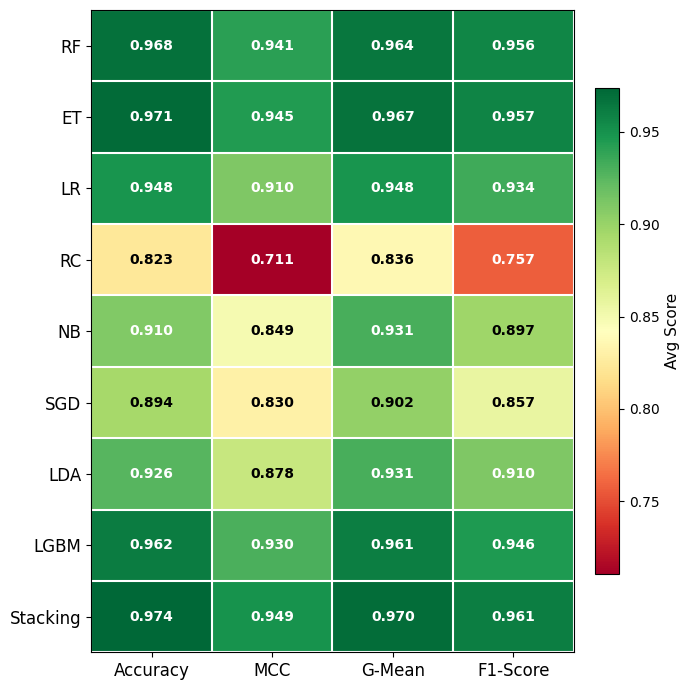

Saved: heatmap_avg_all_dfs.png


In [12]:
import numpy as np
import matplotlib.pyplot as plt
raw = {
    "D-FS1": {
        "RF":       [0.965, 0.935, 0.961, 0.952],
        "ET":       [0.968, 0.942, 0.964, 0.956],
        "LR":       [0.950, 0.912, 0.951, 0.935],
        "RC":       [0.840, 0.734, 0.851, 0.787],
        "NB":       [0.881, 0.806, 0.908, 0.862],
        "SGD":      [0.894, 0.825, 0.897, 0.841],
        "LDA":      [0.913, 0.857, 0.921, 0.898],
        "LGBM":     [0.960, 0.924, 0.955, 0.940],
        "Stacking": [0.975, 0.952, 0.973, 0.964],
    },
    "D-FS2": {
        "RF":       [0.971, 0.947, 0.967, 0.960],
        "ET":       [0.972, 0.944, 0.967, 0.956],
        "LR":       [0.949, 0.910, 0.948, 0.932],
        "RC":       [0.830, 0.716, 0.840, 0.763],
        "NB":       [0.898, 0.829, 0.921, 0.883],
        "SGD":      [0.881, 0.816, 0.897, 0.850],
        "LDA":      [0.928, 0.882, 0.933, 0.914],
        "LGBM":     [0.964, 0.935, 0.962, 0.947],
        "Stacking": [0.972, 0.946, 0.968, 0.957],
    },
    "D-FS3": {
        "RF":       [0.969, 0.943, 0.965, 0.957],
        "ET":       [0.969, 0.941, 0.966, 0.956],
        "LR":       [0.943, 0.902, 0.944, 0.929],
        "RC":       [0.812, 0.695, 0.828, 0.744],
        "NB":       [0.919, 0.864, 0.938, 0.908],
        "SGD":      [0.898, 0.835, 0.903, 0.859],
        "LDA":      [0.932, 0.886, 0.934, 0.914],
        "LGBM":     [0.961, 0.928, 0.961, 0.946],
        "Stacking": [0.975, 0.950, 0.971, 0.962],
    },
    "D-FS4": {
        "RF":       [0.964, 0.934, 0.961, 0.952],
        "ET":       [0.971, 0.947, 0.968, 0.957],
        "LR":       [0.949, 0.912, 0.948, 0.935],
        "RC":       [0.820, 0.714, 0.836, 0.750],
        "NB":       [0.930, 0.880, 0.946, 0.920],
        "SGD":      [0.908, 0.849, 0.914, 0.878],
        "LDA":      [0.932, 0.888, 0.936, 0.920],
        "LGBM":     [0.963, 0.932, 0.964, 0.948],
        "Stacking": [0.972, 0.947, 0.969, 0.959],
    },
    "D-FS5": {
        "RF":       [0.971, 0.947, 0.968, 0.961],
        "ET":       [0.974, 0.949, 0.971, 0.961],
        "LR":       [0.950, 0.916, 0.951, 0.939],
        "RC":       [0.812, 0.694, 0.827, 0.741],
        "NB":       [0.921, 0.867, 0.940, 0.910],
        "SGD":      [0.891, 0.827, 0.900, 0.858],
        "LDA":      [0.923, 0.876, 0.929, 0.906],
        "LGBM":     [0.963, 0.933, 0.962, 0.947],
        "Stacking": [0.974, 0.951, 0.971, 0.963],
    },
}

# ── CONFIG ────────────────────────────────────────────────────────────────────

datasets = ["D-FS1", "D-FS2", "D-FS3", "D-FS4", "D-FS5"]
models   = ["RF", "ET", "LR", "RC", "NB", "SGD", "LDA", "LGBM", "Stacking"]
metrics  = ["Accuracy", "MCC", "G-Mean", "F1-Score"]   # ← AUROC বাদ

# ── STEP 1: প্রতিটা model-এর সব D-FS এর average ─────────────────────────────

avg_grid = np.full((len(models), len(metrics)), np.nan)

for i, model in enumerate(models):
    for k, metric in enumerate(metrics):
        vals = []
        for ds in datasets:
            # Fix: Changed 'data' to 'raw'
            v = raw[ds][model][k] # Access using index k instead of metric name
            if v is not None:
                vals.append(v)
        if vals:
            avg_grid[i, k] = np.mean(vals)

# ── STEP 2: heatmap ───────────────────────────────────────────────────────────

cmap   = plt.cm.RdYlGn
vmin   = np.nanmin(avg_grid)
vmax   = np.nanmax(avg_grid)
masked = np.ma.masked_invalid(avg_grid)

fig, ax = plt.subplots(figsize=(7, 7))
im      = ax.imshow(masked, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")

for i in range(len(models)):
    for k in range(len(metrics)):
        val      = avg_grid[i, k]
        norm_val = (val - vmin) / (vmax - vmin)
        txt_col  = "white" if (norm_val < 0.25 or norm_val > 0.75) else "black"
        ax.text(k, i, f"{val:.3f}", ha="center", va="center",
                fontsize=10, color=txt_col, fontweight="bold")

ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(metrics, fontsize=12)
ax.set_yticks(range(len(models)))
ax.set_yticklabels(models, fontsize=12)

ax.set_xticks(np.arange(-0.5, len(metrics), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(models), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.ax.tick_params(labelsize=10)
cb.set_label("Avg Score", fontsize=11)

plt.tight_layout()
plt.savefig("heatmap_avg_all_dfs.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: heatmap_avg_all_dfs.png")